# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

I would use the pipeline of the first day (url:"https://nf-co.re/differentialabundance/2.0.0/", date:30.09.2026), the differential abundance pipeline. It is even explicitly stated in the introduction, that it supports rnaseq results.

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [14]:
# Note: to get the samplesheet, I will use pandas to create it
import pandas as pd 

count_table =pd.read_csv("data/salmon.merged.gene_counts.tsv", sep="\t")
conditions = []
for entry in count_table.columns[2:]:
    split = entry.split("_")
    entry = f"{split[0]}_{split[1]}"
    conditions.append(entry)

samplesheet= pd.DataFrame({
    "sample":count_table.columns[2:],
    "Condition":conditions
})
samplesheet.to_csv("./data/samplesheet.csv", index=False)

Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [ ]:
!nextflow run nf-core/differentialabundance -r 2.0.0 -profile podman --study_name "oxycodon_mus_musculus" --study-type "rnaseq" --input "./data/samplesheet.csv" --contrasts "data/contrasts.csv" --matrix "./data/salmon.merged.gene_counts.tsv" --genome "GRCm38" --outdir "./analysis"

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

1. --study_name: necessary identifier for the output of the run
2. --study_type: input data format 
3. --input: I set it to the created samplesheet csv file, containing sample information in the experiment
4. --contrasts: I set it to the given contrast file in the data folder. It contains information on which comparison to make between groups
5. --maxtrix: I set it to the count table given in the data, containing gene expression information (bulk rna-seq) for each condition and group combination
6. --genome: I genome ID for reference genome for gene length information and normalisation
7. --outdir: path to my outputfolder 

What were the outputs of the pipeline?

The pipeline result folder contains several outputs. 

- It contains a plots folder, containing several stand-alone plots.

- Next, there is a tables folder, containing tables with the main differential statistics.

- Furthermore, it also contains pipeline information reports, giving insights into excecution, run time, or also launch commands and more of the pipeline

- It also contains a report, giving an overview over the whole run and differential analysis results.

Would you exclude any samples? If yes, which and why?

To evaluate, which to exclude, I look at the 3d PCA and the sample dendrogram in the results:

![3d_pca](./analysis/plots/exploratory/contrasts/Condition/png/pca3d.png)

![dendro](./analysis/plots/exploratory/contrasts/Condition/png/sample_dendrogram.png)

In both the dendrogram and the PCA, SNI-Sal 2 and 4 are far away from the other sample points, hence, outlier. In the dendrogram they cluster together, but don't show any similarity with the other to samples with the same group. Same for the PCA, where they are far away and don't cluster anyhow with the other samples of the same group.
To conclude, I would exclude, based on these observations, SNI-Sal 2 and 4.

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

For this to answer, I have to create a new contrast csv containing the comparisons in the paper.
I save this as 'contrast_alt.csv' and rerun the pipeline with the following command:

!nextflow run nf-core/differentialabundance -r 2.0.0 -profile podman --study_name "oxycodon_mus_musculus" --study-type "rnaseq" --input "./data/samplesheet.csv" --contrasts "data/contrasts_alt.csv" --matrix "./data/salmon.merged.gene_counts.tsv" --genome "GRCm38" --outdir "./analysis_alt"

From this run, we get the following results:
|                                     |up|down|
|-------------------------------------|--|----|
|Sham_Sal versus SNI_Sal in Condition | 1| 73 |
|Sham_Sal versus Sham_oxy in Condition| 0| 7  |
|Sham_Sal versus SNI_oxy in Condition | 0| 1  |

My results differ greatly to the ones in the paper. In the paper, the authors show nearly a hundred to several hundred genes per contrast, whereas my biggest number is 74, followed by 7 and 1 genes in the contrasts.

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

- NAc: Is the nucleus accumbens,which is a part of the reward system and plays an important role in processing rewarding and reinforcing stimuli.

- mPFC: Is the medial prefrontal cortex, which plays an essential role in emotional regulation, decision making and cognition.

- VTA: Is the ventral tegmental area, which is the origin of the dopaminergic cell bodies of dopamin pathways. Hence, it plays important roles in processes like reward cognition.

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

No. Normally such data would be listed in available or supplementary data. But while reading the paper, I couldn't find such information for the genes for this specific experiment. 

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

No, only the list would not be sufficient. Preferably, to get the most complete picture of the whole analysis, we also need context and relevent biological background information for the gene expression list.

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentioned.

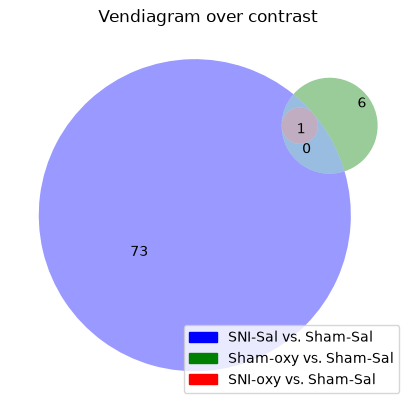

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib.patches import Patch

# define groups for venndiagram
group_test_1 = set(pd.read_csv("analysis_alt/tables/differential/contrasts/test_1_oxycodon_mus_musculus.deseq2.results_filtered.tsv", sep="\t", index_col=0).index)
group_test_2 = set(pd.read_csv("analysis_alt/tables/differential/contrasts/test_2_oxycodon_mus_musculus.deseq2.results_filtered.tsv", sep="\t", index_col=0).index)
group_test_3 = set(pd.read_csv("analysis_alt/tables/differential/contrasts/test_3_oxycodon_mus_musculus.deseq2.results_filtered.tsv", sep="\t", index_col=0).index)

# plot venndiagram
venn3(
    [group_test_1, group_test_2, group_test_3],
    #set_labels=("SNI-Sal vs. Sham-Sal","Sham-oxy vs. Sham-Sal","SNI-Sal vs. Sham-Sal")
    set_labels=None,
    set_colors=("red","green","blue")
)
plt.legend(
    handles=[
        Patch(color="blue", label="SNI-Sal vs. Sham-Sal"),
        Patch(color="green", label="Sham-oxy vs. Sham-Sal"),
        Patch(color="red", label="SNI-oxy vs. Sham-Sal")
    ],
    loc="lower right"
)

plt.title("Vendiagram over contrast")
plt.show()